# **Assignment 1: Demand prediction of bike sharing system**

Bike sharing services are nowadays spread all over the world. They are beneficial for cities as they offer a climate neutral and healthy way of transportation. Moreover, similar to e-scooters, for the companies and transportation researchers they generate valuable data. This includes the trip route, trip origins and destinations, duration, and much more.

In this assignment we use a public bike sharing dataset from Washington, D.C., USA. published by Fanaee-T, H. (2013). Bike Sharing [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5W894.

## Your Task

Your task in this assignment is:

1) to predict the demand of hourly rentals (**target-column: cnt**) using the [XGBoost](https://xgboost.readthedocs.io/en/stable/) and linear regression model. In this notebook we have provided you with the basic structure how to approach the problem. Feel free to reuse and improve parts of the exercise material.

2) After you have created the model please upload your code to Github and post the link to the notebook in the corresponding forum for the assignment with a short text describing how you have solved the task.

## Load data

You can also find more information about the data and the columns at: https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset

In [4]:
import pandas as pd

url = 'https://raw.githubusercontent.com/zhenliangma/Applied-AI-in-Transportation/master/Exercise_2_regression_model/Exercise2BikeSharing.csv'
df = pd.read_csv(url)

#df = pd.read_csv('Exercise2BikeSharing.csv')
df.head(10)

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,0,1,1
5,6,2011-01-01,1,0,1,5,0,6,0,2,0.24,0.2576,0.75,0.0896,0,1,1
6,7,2011-01-01,1,0,1,6,0,6,0,1,0.22,0.2727,0.80,0.0000,2,0,2
7,8,2011-01-01,1,0,1,7,0,6,0,1,0.20,0.2576,0.86,0.0000,1,2,3
8,9,2011-01-01,1,0,1,8,0,6,0,1,0.24,0.2879,0.75,0.0000,1,7,8
9,10,2011-01-01,1,0,1,9,0,6,0,1,0.32,0.3485,0.76,0.0000,8,6,14


In [5]:
df.shape

(17379, 17)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


## Train / Test split
- Target: `cnt` (count of total rental bikes including both casual and registered)
- Predictors: weather (`temp`, `atemp`, `hum`, `windspeed`, `weathersit`), calendar (`hr`, `weekday`, `workingday`, `holiday`, `season`), and `yr`.
- We keep it simple; you can expand features (e.g., interactions) later.

In [7]:
from sklearn.model_selection import train_test_split
target = 'cnt'

X = df.copy()
y = df[target].astype(float)

X.drop(columns=[target], inplace=True)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


## Data Processing / Feature Engineering

Before training the model think about data processing and feature engineering steps if applicable, such as:
- adding/removal of features
- normalization
- one hot encoding
- ...


=== Linear Regression Results ===
MAE:  74.11
RMSE: 100.45
R2:   0.6814

=== XGBoost Regressor Results ===
MAE:  34.16
RMSE: 50.99
R2:   0.9179


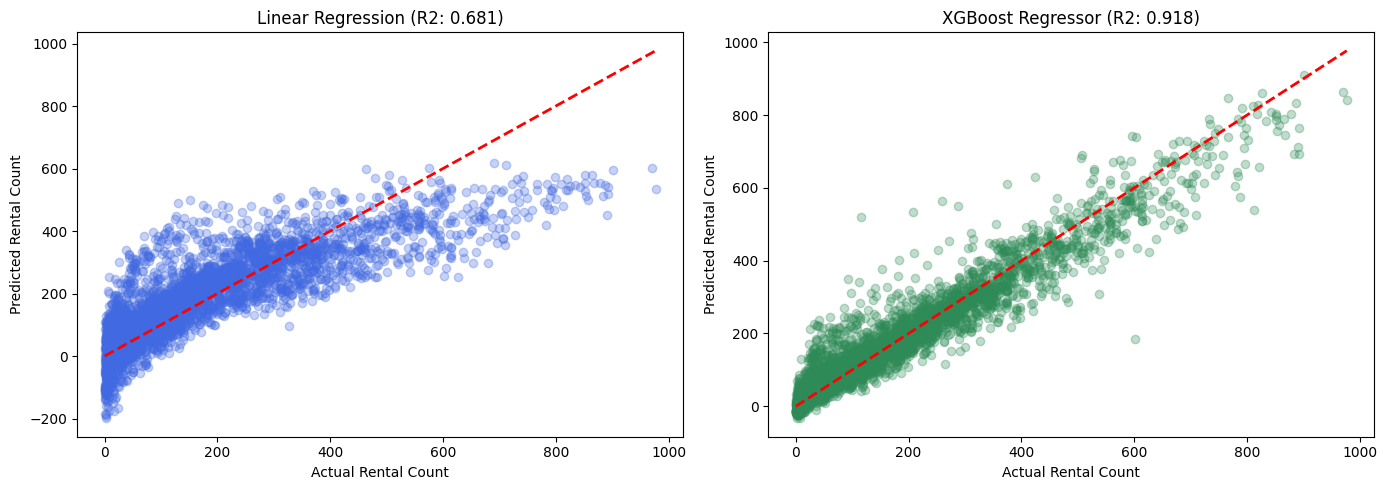

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Load dataset
url = 'https://raw.githubusercontent.com/zhenliangma/Applied-AI-in-Transportation/master/Exercise_2_regression_model/Exercise2BikeSharing.csv'
df = pd.read_csv(url)

# 2. Data Preprocessing & Feature Engineering
# instant, dteday: identifier / date
# casual, registered: sum up to cnt (dropped to avoid data leakage)
drop_cols = ['instant', 'dteday', 'casual', 'registered', 'cnt']
X = df.drop(columns=drop_cols)
y = df['cnt']

# One-Hot Encoding for categorical features
categorical_cols = ['season', 'mnth', 'hr', 'weekday', 'weathersit']
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# 3. Train / Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling for Linear Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Model 1: Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)

# 5. Model 2: XGBoost Regressor
xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

# 6. Print Evaluation Metrics
print("=== Linear Regression Results ===")
print(f"MAE:  {mean_absolute_error(y_test, y_pred_lr):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_lr)):.2f}")
print(f"R2:   {r2_score(y_test, y_pred_lr):.4f}\n")

print("=== XGBoost Regressor Results ===")
print(f"MAE:  {mean_absolute_error(y_test, y_pred_xgb):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_xgb)):.2f}")
print(f"R2:   {r2_score(y_test, y_pred_xgb):.4f}")

# 7. Visualization (Actual vs. Predicted Values)
plt.figure(figsize=(14, 5))

# Linear Regression plot
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_lr, alpha=0.3, color='royalblue')
plt.plot([0, y_test.max()], [0, y_test.max()], '--r', lw=2)
plt.title(f"Linear Regression (R2: {r2_score(y_test, y_pred_lr):.3f})")
plt.xlabel("Actual Rental Count")
plt.ylabel("Predicted Rental Count")

# XGBoost plot
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_xgb, alpha=0.3, color='seagreen')
plt.plot([0, y_test.max()], [0, y_test.max()], '--r', lw=2)
plt.title(f"XGBoost Regressor (R2: {r2_score(y_test, y_pred_xgb):.3f})")
plt.xlabel("Actual Rental Count")
plt.ylabel("Predicted Rental Count")

plt.tight_layout()
plt.show()

## Hyperparameter optimization
Hyperparameter tuning helps find the best set of hyperparameters for your model. Use Grid Search or Random Search with Cross Validation from scikit-learn to search for the best combination of parameters.

In [14]:
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV

# 1. Define parameter search space for XGBoost
param_distributions = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
}

# 2. Initialize RandomizedSearchCV (20 iterations, 5-fold cross-validation)
xgb_base = xgb.XGBRegressor(random_state=42)

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_distributions,
    n_iter=20,
    scoring='r2',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1,
)

# 3. Run search on training dataset
print("Hyperparameter tuning in progress...")
random_search.fit(X_train, y_train)

# 4. Print best parameters and cross-validation score
print("\nBest Parameters:", random_search.best_params_)
print(f"Best CV R2 Score: {random_search.best_score_:.4f}")

# 5. Evaluate best model on test set
best_xgb_model = random_search.best_estimator_
y_pred_tuned = best_xgb_model.predict(X_test)

print("\n=== Tuned XGBoost Test Results ===")
print(f"MAE:  {mean_absolute_error(y_test, y_pred_tuned):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_tuned)):.2f}")
print(f"R2:   {r2_score(y_test, y_pred_tuned):.4f}")

Hyperparameter tuning in progress...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best Parameters: {'subsample': 0.7, 'n_estimators': 500, 'max_depth': 6, 'learning_rate': 0.2, 'colsample_bytree': 0.8}
Best CV R2 Score: 0.9295

=== Tuned XGBoost Test Results ===
MAE:  29.29
RMSE: 45.34
R2:   0.9351


## Train the XGBoost and Linear regression models
Now, create an XGBoost and linear regression model using the best parameters and train them using the training data.

In [15]:
import xgboost as xgb
from sklearn.linear_model import LinearRegression

# 1. Create and train Linear Regression model (on scaled training data)
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
print("Linear Regression model trained successfully.")

# 2. Create XGBoost model using best hyperparameters from Grid/Random Search
xgb_best_params = random_search.best_params_

best_xgb_model = xgb.XGBRegressor(
    **xgb_best_params,
    random_state=42
)

# Train XGBoost model on full training data
best_xgb_model.fit(X_train, y_train)
print("XGBoost model (with best parameters) trained successfully.")

Linear Regression model trained successfully.
XGBoost model (with best parameters) trained successfully.


## Make predictions
Use the trained models to make predictions on the test data and compare the performance of the XGBoost and linear regression models using metrics like Mean Squared Error (MSE) and R-squared.

In [16]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Make predictions on the test dataset
y_pred_lr = lr_model.predict(X_test_scaled)
y_pred_xgb = best_xgb_model.predict(X_test)

# 2. Compute evaluation metrics for Linear Regression
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

# 3. Compute evaluation metrics for XGBoost Regressor
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

# 4. Display results side-by-side in a comparative DataFrame
comparison_df = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R-squared (R2)'],
    'Linear Regression': [mae_lr, mse_lr, rmse_lr, r2_lr],
    'Tuned XGBoost': [mae_xgb, mse_xgb, rmse_xgb, r2_xgb]
})

print("=== Model Performance Comparison on Test Set ===")
print(comparison_df.round(4).to_string(index=False))

=== Model Performance Comparison on Test Set ===
        Metric  Linear Regression  Tuned XGBoost
           MAE            74.1052        29.2889
           MSE         10089.3881      2055.7979
          RMSE           100.4459        45.3409
R-squared (R2)             0.6814         0.9351


## Visualize the predictions and compare the mdoels
Create a "Actual vs. Predicted Values" graph to give a visual inspection of the prediction quality.

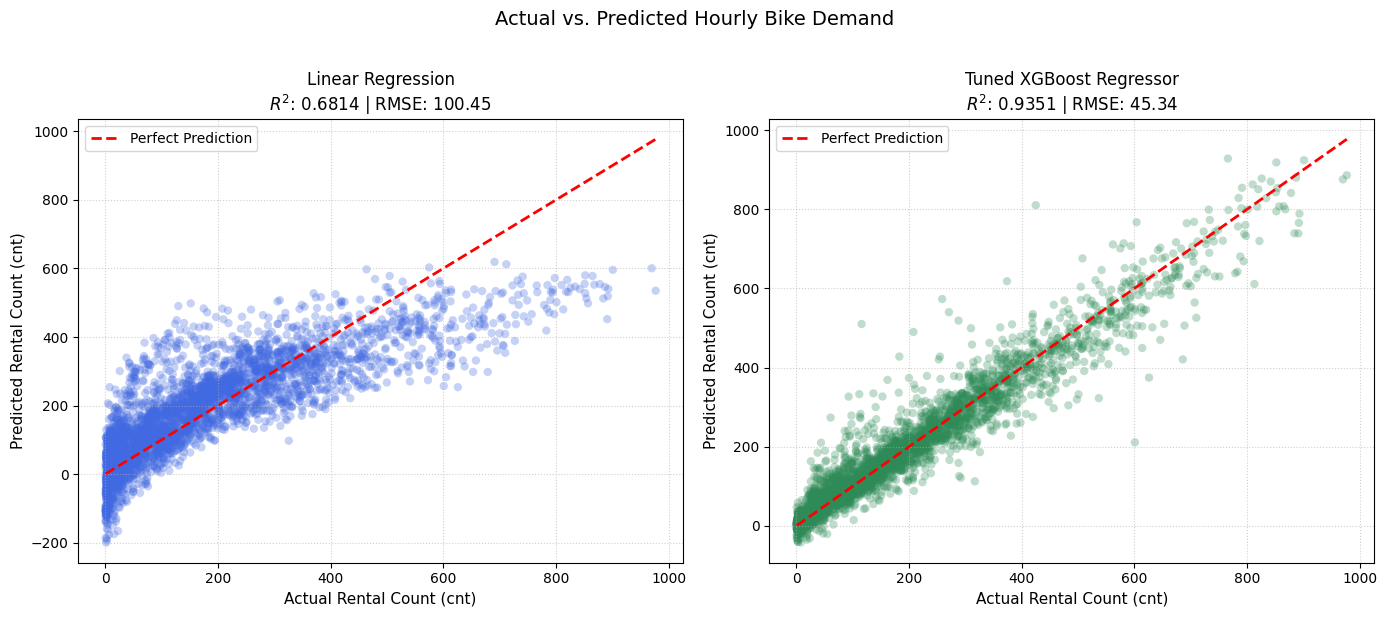

In [18]:
import matplotlib.pyplot as plt

# Set the overall plot style and figure size
plt.figure(figsize=(14, 6))

# Plot 1: Linear Regression
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_lr, alpha=0.3, color='royalblue', edgecolor='none')
# Perfect prediction reference line (y = x)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         linestyle='--', color='red', lw=2, label='Perfect Prediction')
plt.title(f'Linear Regression\n$R^2$: {r2_lr:.4f} | RMSE: {rmse_lr:.2f}', fontsize=12)
plt.xlabel('Actual Rental Count (cnt)', fontsize=11)
plt.ylabel('Predicted Rental Count (cnt)', fontsize=11)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

# Plot 2: Tuned XGBoost
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_xgb, alpha=0.3, color='seagreen', edgecolor='none')
# Perfect prediction reference line (y = x)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         linestyle='--', color='red', lw=2, label='Perfect Prediction')
plt.title(f'Tuned XGBoost Regressor\n$R^2$: {r2_xgb:.4f} | RMSE: {rmse_xgb:.2f}', fontsize=12)
plt.xlabel('Actual Rental Count (cnt)', fontsize=11)
plt.ylabel('Predicted Rental Count (cnt)', fontsize=11)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.suptitle('Actual vs. Predicted Hourly Bike Demand', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()